In [24]:
!pip install -q sdv optuna lightgbm xgboost catboost joblib



In [25]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import optuna

from lightgbm import LGBMClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

from sklearn.utils.class_weight import compute_class_weight

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
PROJECT_DIR = "/content/drive/MyDrive/Ghana_Dropout_Project"

MODEL_DIR = f"{PROJECT_DIR}/models"

RESULT_DIR = f"{PROJECT_DIR}/results"

FIGURE_DIR = f"{PROJECT_DIR}/figures"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

In [28]:
TARGET = "dropout_label"

df = pd.read_csv(
    f"{PROJECT_DIR}/engineered_data.csv"
)

print(df.shape)

df.head()

(1000, 39)


,school_code,geographic_zone,school_type,data_source,gender,age_at_start_of_academic_year,class_level,grade_repetition_count,term_1_attendance,term_2_attendance,...,school_enjoyment,missed_school_for_choreswork,missed_school_due_to_illness,barriers_to_regular_attendance,family_income_level,parent_attends_school_events,behaviour_warnings_punishments,class_participation,extracurricular_activities,dropout_label
0,1,0,1,1,1,10.0,0,0,85.0,82.0,...,3.0,0,3,3,4,5,2,5.0,0,0
1,1,0,1,1,1,11.0,0,0,87.0,79.0,...,3.0,0,3,3,4,4,3,2.0,1,0
2,1,0,1,1,1,10.0,0,0,70.0,79.0,...,1.0,2,3,0,4,5,2,5.0,1,0
3,1,0,1,1,0,12.0,0,0,80.0,83.0,...,4.0,0,4,3,2,3,2,4.0,1,0
4,1,0,1,1,0,10.0,0,0,77.0,80.0,...,3.0,0,3,3,2,5,2,4.0,0,0


In [29]:
X = df.drop(columns=[TARGET])

y = df[TARGET]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(X_train.shape)
print(X_test.shape)

(800, 38)
(200, 38)


In [31]:
classes = np.unique(y_train)

weights = compute_class_weight(

    class_weight="balanced",

    classes=classes,

    y=y_train

)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5509641873278237), np.int64(1): np.float64(5.405405405405405)}


In [32]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [33]:
def objective(trial):

    params = {

        # Tree complexity
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),

        "max_depth": trial.suggest_int("max_depth", 3, 15),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            100
        ),

        # Learning
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.005,
            0.20,
            log=True
        ),

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            1000
        ),

        # Row sampling
        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        # Column sampling
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        # Regularization
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0.0,
            10.0
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0.0,
            10.0
        ),

        # Class imbalance
        "class_weight": class_weights,

        "objective": "binary",

        "random_state": 42,

        "verbosity": -1
    }

    model = LGBMClassifier(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1
    ).mean()

    return score

In [34]:
study = optuna.create_study(
    direction="maximize",
    study_name="LightGBM_Optimization"
)

[I 2026-06-29 00:48:56,948] A new study created in memory with name: LightGBM_Optimization


In [35]:
study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-29 00:49:11,521] Trial 0 finished with value: 0.9751791621415682 and parameters: {'num_leaves': 64, 'max_depth': 13, 'min_child_samples': 90, 'learning_rate': 0.08335035562462745, 'n_estimators': 509, 'subsample': 0.7098956653518792, 'colsample_bytree': 0.6496231149384089, 'reg_alpha': 6.265756984389482, 'reg_lambda': 4.223340476501375}. Best is trial 0 with value: 0.9751791621415682.
[I 2026-06-29 00:49:12,013] Trial 1 finished with value: 0.9914718614718614 and parameters: {'num_leaves': 141, 'max_depth': 9, 'min_child_samples': 50, 'learning_rate': 0.06173380805528308, 'n_estimators': 781, 'subsample': 0.9951361589168115, 'colsample_bytree': 0.8499004538387055, 'reg_alpha': 1.8970911322634354, 'reg_lambda': 8.928488439161258}. Best is trial 1 with value: 0.9914718614718614.
[I 2026-06-29 00:49:12,305] Trial 2 finished with value: 0.9752640585777232 and parameters: {'num_leaves': 44, 'max_depth': 3, 'min_child_samples': 48, 'learning_rate': 0.1918083284860053, 'n_estimator

In [36]:
print("Best Score:")
print(study.best_value)

print()

print("Best Parameters:")
print(study.best_params)

Best Score:
0.9949242424242424

Best Parameters:
{'num_leaves': 82, 'max_depth': 6, 'min_child_samples': 25, 'learning_rate': 0.18295777665929805, 'n_estimators': 536, 'subsample': 0.9726509965527034, 'colsample_bytree': 0.6130483131165315, 'reg_alpha': 0.37982362685682225, 'reg_lambda': 0.6469351015457592}


In [37]:
study.trials_dataframe().to_csv(
    f"{RESULT_DIR}/optuna_trials.csv",
    index=False
)

In [38]:
# Split the training data into:
# - Training set (80%)
# - Validation set (20%)

X_train_final, X_valid, y_train_final, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print(f"Training samples:   {X_train_final.shape[0]}")
print(f"Validation samples: {X_valid.shape[0]}")
print(f"Test samples:       {X_test.shape[0]}")

Training samples:   640
Validation samples: 160
Test samples:       200


In [39]:
best_params = study.best_params.copy()

best_model = LGBMClassifier(
    **best_params,
    class_weight=class_weights,
    objective="binary",
    random_state=42,
    verbosity=-1
)

best_model.fit(
    X_train_final,
    y_train_final
)

LGBMClassifier(class_weight={np.int64(0): np.float64(0.5509641873278237),
                             np.int64(1): np.float64(5.405405405405405)},
               colsample_bytree=0.6130483131165315,
               learning_rate=0.18295777665929805, max_depth=6,
               min_child_samples=25, n_estimators=536, num_leaves=82,
               objective='binary', random_state=42,
               reg_alpha=0.37982362685682225, reg_lambda=0.6469351015457592,
               subsample=0.9726509965527034, verbosity=-1)

In [40]:
valid_prob = best_model.predict_proba(X_valid)[:, 1]

In [41]:
thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for threshold in thresholds:

    predictions = (valid_prob >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_valid, predictions, zero_division=0),
        "recall": recall_score(y_valid, predictions, zero_division=0),
        "f1": f1_score(y_valid, predictions, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

threshold_results.head()

,threshold,precision,recall,f1
0,0.10,0.789474,1.0,0.882353
1,0.11,0.789474,1.0,0.882353
2,0.12,0.833333,1.0,0.909091
3,0.13,0.833333,1.0,0.909091
4,0.14,0.833333,1.0,0.909091


In [42]:
best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_threshold = best_row["threshold"]

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Validation F1 : {best_row['f1']:.4f}")

Best Threshold: 0.21
Validation F1 : 0.9375


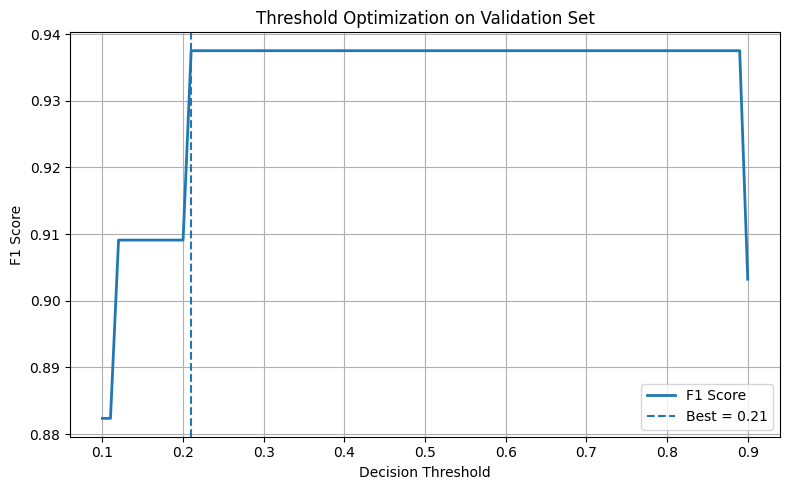

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    linewidth=2,
    label="F1 Score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best = {best_threshold:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Optimization on Validation Set")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/threshold_optimization.png",
    dpi=300
)

plt.show()

In [44]:
# Rebuild the model with the best hyperparameters

final_model = LGBMClassifier(
    **study.best_params,
    class_weight=class_weights,
    objective="binary",
    random_state=42,
    verbosity=-1
)

# Train using ALL training data (800 records)
final_model.fit(
    X_train,
    y_train
)

LGBMClassifier(class_weight={np.int64(0): np.float64(0.5509641873278237),
                             np.int64(1): np.float64(5.405405405405405)},
               colsample_bytree=0.6130483131165315,
               learning_rate=0.18295777665929805, max_depth=6,
               min_child_samples=25, n_estimators=536, num_leaves=82,
               objective='binary', random_state=42,
               reg_alpha=0.37982362685682225, reg_lambda=0.6469351015457592,
               subsample=0.9726509965527034, verbosity=-1)

In [45]:
# Predicted probabilities
test_prob = final_model.predict_proba(X_test)[:, 1]

# Apply the optimized threshold
test_pred = (test_prob >= best_threshold).astype(int)

In [46]:
metrics = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1 Score": f1_score(y_test, test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_prob),
    "PR-AUC": average_precision_score(y_test, test_prob)
}

results_df = pd.DataFrame([metrics])

results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,0.995,1.0,0.944444,0.971429,0.996337,0.977778


In [47]:
results_df.to_csv(
    f"{RESULT_DIR}/engineered_lightgbm_results.csv",
    index=False
)

results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,0.995,1.0,0.944444,0.971429,0.996337,0.977778


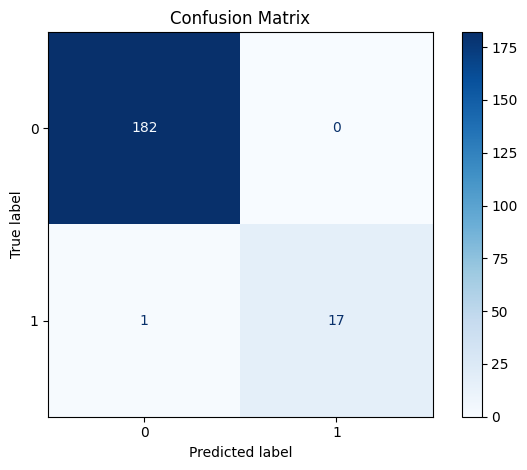

In [48]:
cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/confusion_matrix.png",
    dpi=300
)

plt.show()

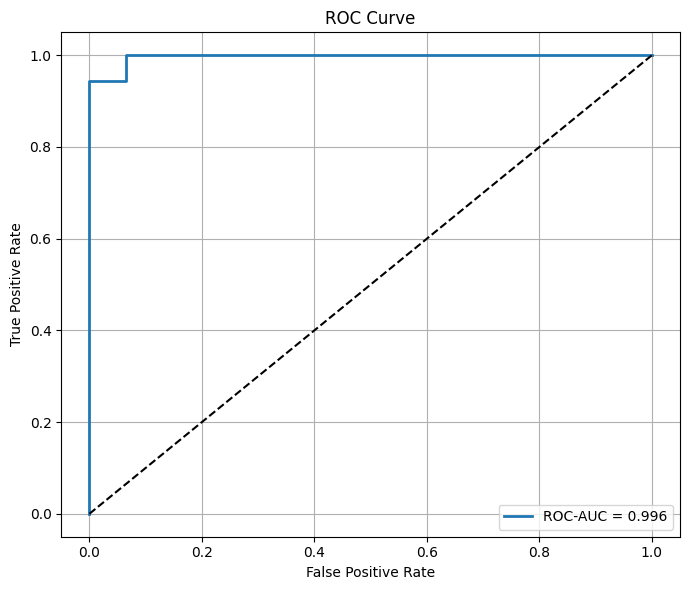

In [49]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, test_prob)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC-AUC = {metrics['ROC-AUC']:.3f}"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/roc_curve.png",
    dpi=300
)

plt.show()

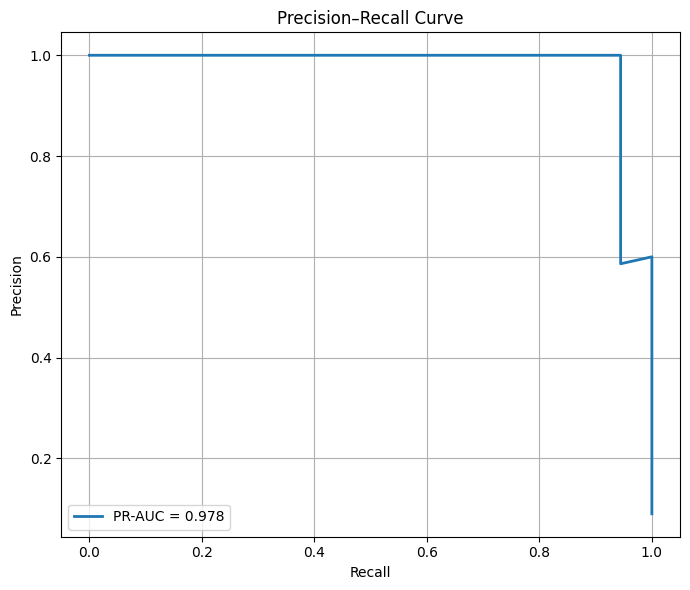

In [50]:
precision, recall, _ = precision_recall_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"PR-AUC = {metrics['PR-AUC']:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/precision_recall_curve.png",
    dpi=300
)

plt.show()

In [51]:
joblib.dump(
    final_model,
    f"{MODEL_DIR}/engineered_lightgbm.pkl"
)

['/content/drive/MyDrive/Ghana_Dropout_Project/models/engineered_lightgbm.pkl']

In [52]:
with open(
    f"{MODEL_DIR}/best_parameters.json",
    "w"
) as f:
    json.dump(
        study.best_params,
        f,
        indent=4
    )

In [53]:
with open(
    f"{MODEL_DIR}/best_threshold.txt",
    "w"
) as f:
    f.write(str(best_threshold))

In [54]:
print("=" * 60)
print("ENGINEERED LIGHTGBM MODEL")
print("=" * 60)

print(f"Best Threshold : {best_threshold:.2f}")
print()

for metric, value in metrics.items():
    print(f"{metric:<12}: {value:.4f}")

print("=" * 60)

ENGINEERED LIGHTGBM MODEL
Best Threshold : 0.21

Accuracy    : 0.9950
Precision   : 1.0000
Recall      : 0.9444
F1 Score    : 0.9714
ROC-AUC     : 0.9963
PR-AUC      : 0.9778
